In [1]:
# ============================================================
# CELL 1 — IMPORT
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

print('✅ Import thành công!')

✅ Import thành công!


In [2]:
# ============================================================
# CELL 2 — LOAD DATA
# ============================================================
df = pd.read_csv('clean_no_outlier.csv')

counts = df['Loan_Status'].value_counts()
total  = len(df)

print('=' * 50)
print('       THÔNG TIN DỮ LIỆU ĐẦU VÀO')
print('=' * 50)
print(f'Nguồn      : clean_no_outlier.csv (từ Phần 2)')
print(f'Kích thước : {df.shape[0]} hồ sơ × {df.shape[1]} cột')
print(f'Cột        : {df.columns.tolist()}')
print(f'Missing    : {df.isnull().sum().sum()} ô ← Phần 2 đã xử lý')
print()
print('Phân phối nhãn Loan_Status:')
print(f'  Được duyệt (1) : {counts[1]:>4} hồ sơ = {counts[1]/total*100:.1f}%')
print(f'  Từ chối   (0)  : {counts[0]:>4} hồ sơ = {counts[0]/total*100:.1f}%')
print(f'  Mất cân bằng   : {counts[1]/counts[0]:.2f} lần')
print('⚠️  Mất cân bằng 69/31 → dùng F1 làm chỉ số đánh giá chính')
df.head()

       THÔNG TIN DỮ LIỆU ĐẦU VÀO
Nguồn      : clean_no_outlier.csv (từ Phần 2)
Kích thước : 571 hồ sơ × 7 cột
Cột        : ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']
Missing    : 0 ô ← Phần 2 đã xử lý

Phân phối nhãn Loan_Status:
  Được duyệt (1) :  394 hồ sơ = 69.0%
  Từ chối   (0)  :  177 hồ sơ = 31.0%
  Mất cân bằng   : 2.23 lần
⚠️  Mất cân bằng 69/31 → dùng F1 làm chỉ số đánh giá chính


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,5849,0.0,128.0,360.0,1.0,1,1
1,4583,1508.0,128.0,360.0,1.0,0,0
2,3000,0.0,66.0,360.0,1.0,1,1
3,2583,2358.0,120.0,360.0,1.0,1,1
4,6000,0.0,141.0,360.0,1.0,1,1


In [3]:
# ============================================================
# CELL 3 — PHÂN CHIA TRAIN/TEST
# ============================================================
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

train_idx = np.load('train_idx.npy')
test_idx  = np.load('test_idx.npy')

X_train_raw = X.iloc[train_idx].reset_index(drop=True)
X_test_raw  = X.iloc[test_idx].reset_index(drop=True)
y_train     = y.iloc[train_idx].reset_index(drop=True)
y_test      = y.iloc[test_idx].reset_index(drop=True)

print('=== PHÂN CHIA DỮ LIỆU ===')
print(f'Tổng : {len(df)} hồ sơ')
print(f'Train: {len(X_train_raw)} hồ sơ (80%)')
print(f'Test : {len(X_test_raw)} hồ sơ (20%)')
print()
print('Tỉ lệ nhãn — Train:',
      f"Duyệt={y_train.mean()*100:.1f}%",
      f"Từ chối={(1-y_train.mean())*100:.1f}%")
print('Tỉ lệ nhãn — Test :',
      f"Duyệt={y_test.mean()*100:.1f}%",
      f"Từ chối={(1-y_test.mean())*100:.1f}%")
print('✅ Dùng cùng train/test với Phần 3')

=== PHÂN CHIA DỮ LIỆU ===
Tổng : 571 hồ sơ
Train: 456 hồ sơ (80%)
Test : 115 hồ sơ (20%)

Tỉ lệ nhãn — Train: Duyệt=68.6% Từ chối=31.4%
Tỉ lệ nhãn — Test : Duyệt=70.4% Từ chối=29.6%
✅ Dùng cùng train/test với Phần 3


=== KẾT QUẢ KHI SCALE SAI (StandardScaler toàn bộ) ===
KNN (K=17)          : Accuracy=83.48%  F1=89.27%
Decision Tree (depth=1) : Accuracy=83.48%  F1=89.27%

⚠️  Hai mô hình cho kết quả GIỐNG HỆT NHAU!
   → Bất thường: KNN và DT có cơ chế học hoàn toàn khác nhau
   → Cần tìm nguyên nhân...


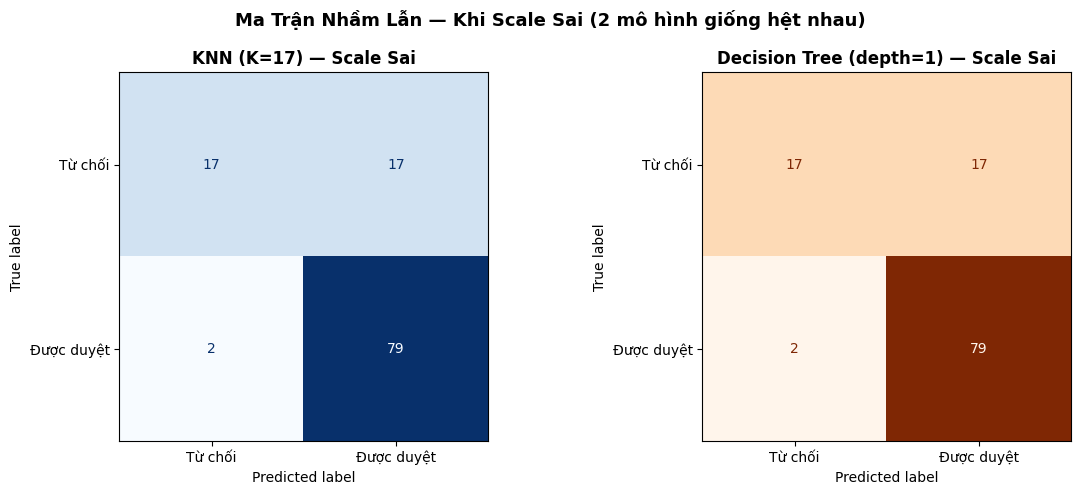

In [ ]:
# ============================================================
# CELL 4 — THỬ NGHIỆM BAN ĐẦU & PHÁT HIỆN BẤT THƯỜNG
# ============================================================
scaler_wrong = StandardScaler()
X_train_wrong = scaler_wrong.fit_transform(X_train_raw)
X_test_wrong  = scaler_wrong.transform(X_test_raw)

# KNN
k_range   = range(1, 21)
knn_f1_cv = []
kf = StratifiedKFold(n_splits=5, shuffle=False)

for k in k_range:
    fold_f1 = []
    for train_fold, val_fold in kf.split(X_train_wrong, y_train):
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train_wrong[train_fold], y_train.iloc[train_fold])
        fold_f1.append(f1_score(y_train.iloc[val_fold],
                                knn.predict(X_train_wrong[val_fold])))
    knn_f1_cv.append(np.mean(fold_f1))

best_k_wrong = list(k_range)[np.argmax(knn_f1_cv)]
knn_wrong = KNeighborsClassifier(n_neighbors=best_k_wrong)
knn_wrong.fit(X_train_wrong, y_train)
y_pred_knn_wrong = knn_wrong.predict(X_test_wrong)
acc_knn_wrong = accuracy_score(y_test, y_pred_knn_wrong)
f1_knn_wrong  = f1_score(y_test, y_pred_knn_wrong)

# Decision Tree
depth_range = range(1, 16)
dt_f1_cv    = []

for depth in depth_range:
    fold_f1 = []
    for train_fold, val_fold in kf.split(X_train_wrong, y_train):
        dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
        dt.fit(X_train_wrong[train_fold], y_train.iloc[train_fold])
        fold_f1.append(f1_score(y_train.iloc[val_fold],
                                dt.predict(X_train_wrong[val_fold])))
    dt_f1_cv.append(np.mean(fold_f1))

best_depth_wrong = list(depth_range)[np.argmax(dt_f1_cv)]
dt_wrong = DecisionTreeClassifier(max_depth=best_depth_wrong, random_state=42)
dt_wrong.fit(X_train_wrong, y_train)
y_pred_dt_wrong = dt_wrong.predict(X_test_wrong)
acc_dt_wrong = accuracy_score(y_test, y_pred_dt_wrong)
f1_dt_wrong  = f1_score(y_test, y_pred_dt_wrong)

# Kết quả
print('=== KẾT QUẢ KHI SCALE SAI (StandardScaler toàn bộ) ===')
print(f'KNN (K={best_k_wrong})          : Accuracy={acc_knn_wrong*100:.2f}%  F1={f1_knn_wrong*100:.2f}%')
print(f'Decision Tree (depth={best_depth_wrong}) : Accuracy={acc_dt_wrong*100:.2f}%  F1={f1_dt_wrong*100:.2f}%')
print()
if f1_knn_wrong == f1_dt_wrong:
    print('⚠️  Hai mô hình cho kết quả GIỐNG HỆT NHAU!')
    print('   → Bất thường: KNN và DT có cơ chế học hoàn toàn khác nhau')
    print('   → Cần tìm nguyên nhân...')

# Ma trận nhầm lẫn
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_knn_wrong),
    display_labels=['Từ chối', 'Được duyệt']
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'KNN (K={best_k_wrong}) — Scale Sai', fontweight='bold')

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_dt_wrong),
    display_labels=['Từ chối', 'Được duyệt']
).plot(ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title(f'Decision Tree (depth={best_depth_wrong}) — Scale Sai',
                  fontweight='bold')

plt.suptitle('Ma Trận Nhầm Lẫn — Khi Scale Sai (2 mô hình giống hệt nhau)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_wrong.png', dpi=150)
plt.show()

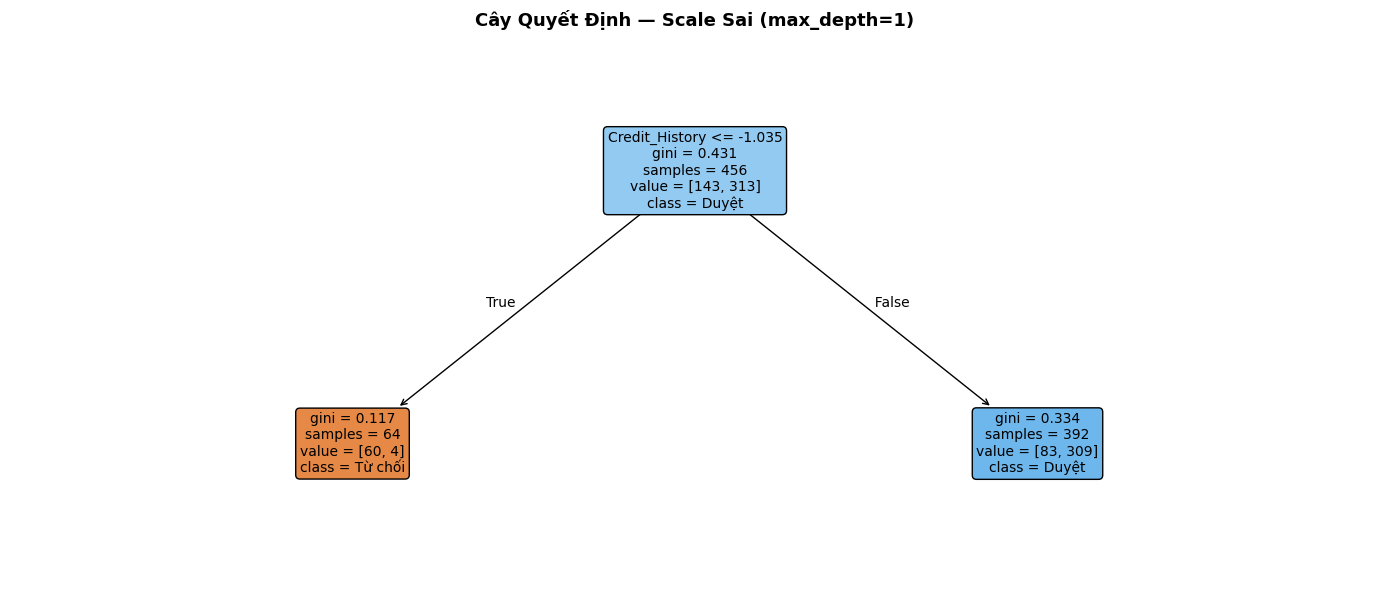

=== PHÁT HIỆN BẤT THƯỜNG TRÊN CÂY QUYẾT ĐỊNH ===

Node gốc: Credit_History <= -1.035
📌 Trích dẫn Phần 2:
   Kiểm định Mann-Whitney/t-test cho 4 biến liên tục
   đều cho p-value "ns" (không có ý nghĩa thống kê)
   → Các biến liên tục không phân biệt được nhãn tốt
   → Credit_History là biến duy nhất có tín hiệu mạnh
   → Scale sai khiến CH càng chi phối cả KNN lẫn DT


In [13]:
# ============================================================
# CELL 5 — BƯỚC 3: VẼ CÂY → PHÁT HIỆN NGƯỠNG BẤT THƯỜNG
# ============================================================
fig, ax = plt.subplots(figsize=(14, 6))
plot_tree(
    dt_wrong,
    feature_names=X.columns.tolist(),
    class_names=['Từ chối', 'Duyệt'],
    filled=True, rounded=True, fontsize=10, ax=ax
)
ax.set_title(f'Cây Quyết Định — Scale Sai (max_depth={best_depth_wrong})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cay_quyet_dinh_wrong.png', dpi=150)
plt.show()

print('=== PHÁT HIỆN BẤT THƯỜNG TRÊN CÂY QUYẾT ĐỊNH ===')
print()
print('Node gốc: Credit_History <= -1.035')

print('📌 Trích dẫn Phần 2:')
print('   Kiểm định Mann-Whitney/t-test cho 4 biến liên tục')
print('   đều cho p-value "ns" (không có ý nghĩa thống kê)')
print('   → Các biến liên tục không phân biệt được nhãn tốt')
print('   → Credit_History là biến duy nhất có tín hiệu mạnh')
print('   → Scale sai khiến CH càng chi phối cả KNN lẫn DT')

In [7]:
# ============================================================
# CELL 6 — BƯỚC 4: MINH HỌA KHOẢNG CÁCH EUCLIDEAN BỊ CHI PHỐI
# ============================================================
print('=' * 60)
print('  PHÂN TÍCH 1: PHƯƠNG SAI SAU KHI SCALE SAI')
print('=' * 60)

feature_names = X_train_raw.columns.tolist()
var_wrong = np.var(scaler_wrong.transform(X_train_raw), axis=0)
var_natural = np.var(X_train_raw.values, axis=0)

df_var = pd.DataFrame({
    'Biến'        : feature_names,
    'Var_Natural' : var_natural,
    'Var_SaiCach' : var_wrong,
})
print(df_var.to_string(index=False))
print()
print('📌 Scale sai: tất cả biến đều có variance ≈ 1')
print(f'   Var tự nhiên của Credit_History = {np.var(X_train_raw["Credit_History"].values):.4f}')
print(f'   → CH chỉ có 2 giá trị nhưng được đưa về cùng scale')
print(f'     với ApplicantIncome (hàng nghìn đến hàng triệu)')

print()
print('=' * 60)
print('  PHÂN TÍCH 2: KHOẢNG CÁCH EUCLIDEAN BỊ CHI PHỐI')
print('=' * 60)

mean_vals = X_train_raw.mean()
std_vals  = X_train_raw.std()
cols      = X_train_raw.columns

base    = mean_vals.copy(); base['Credit_History'] = 1
point_A = base.copy();      point_A['Credit_History'] = 0
point_B = base.copy();      point_B['ApplicantIncome'] = base['ApplicantIncome'] + 2 * std_vals['ApplicantIncome']

v_base = scaler_wrong.transform([base[cols].values])[0]
v_A    = scaler_wrong.transform([point_A[cols].values])[0]
v_B    = scaler_wrong.transform([point_B[cols].values])[0]

dist_ch  = np.sqrt(np.sum((v_base - v_A) ** 2))
dist_inc = np.sqrt(np.sum((v_base - v_B) ** 2))

print(f'Khoảng cách khi CHỈ khác Credit_History (0 vs 1) : {dist_ch:.4f}')
print(f'Khoảng cách khi CHỈ khác ApplicantIncome (+2 std) : {dist_inc:.4f}')
print()
if dist_ch > dist_inc:
    print(f'⚠️  Khác CH tạo khoảng cách {dist_ch/dist_inc:.2f}x LỚN HƠN')
    print(f'   khác thu nhập 2 std → KNN bầu chọn theo CH là chủ yếu!')

print()
print('=' * 60)
print('  KẾT LUẬN NGUYÊN NHÂN')
print('=' * 60)
print('→ StandardScaler áp dụng cho biến nhị phân Credit_History')
print('  khiến CH thống trị không gian đặc trưng')
print('→ Cả KNN (khoảng cách) lẫn DT (ngưỡng phân chia)')
print('  đều bị CH chi phối hoàn toàn → 2 mô hình hội tụ')
print()
print('✅ Fix: chỉ scale biến liên tục, giữ nguyên CH và Property_Area')

  PHÂN TÍCH 1: PHƯƠNG SAI SAU KHI SCALE SAI
             Biến  Var_Natural  Var_SaiCach
  ApplicantIncome 4.982478e+06          1.0
CoapplicantIncome 2.828249e+06          1.0
       LoanAmount 2.887903e+03          1.0
 Loan_Amount_Term 4.548366e+03          1.0
   Credit_History 1.206525e-01          1.0
    Property_Area 6.563895e-01          1.0

📌 Scale sai: tất cả biến đều có variance ≈ 1
   Var tự nhiên của Credit_History = 0.1207
   → CH chỉ có 2 giá trị nhưng được đưa về cùng scale
     với ApplicantIncome (hàng nghìn đến hàng triệu)

  PHÂN TÍCH 2: KHOẢNG CÁCH EUCLIDEAN BỊ CHI PHỐI
Khoảng cách khi CHỈ khác Credit_History (0 vs 1) : 2.8789
Khoảng cách khi CHỈ khác ApplicantIncome (+2 std) : 2.0022

⚠️  Khác CH tạo khoảng cách 1.44x LỚN HƠN
   khác thu nhập 2 std → KNN bầu chọn theo CH là chủ yếu!

  KẾT LUẬN NGUYÊN NHÂN
→ StandardScaler áp dụng cho biến nhị phân Credit_History
  khiến CH thống trị không gian đặc trưng
→ Cả KNN (khoảng cách) lẫn DT (ngưỡng phân chia)
  đều bị C

=== PIPELINE SAU KHI FIX ===
Scale   : ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']
Giữ nguyên: ['Credit_History', 'Property_Area']
Credit_History sau fix — unique values: [0. 1.] ✅

=== SO SÁNH TRƯỚC VÀ SAU KHI FIX ===
                                  Scale Sai   Scale Đúng
--------------------------------------------------------
KNN F1-score                         89.27%       81.87%
DT  F1-score                         89.27%       89.27%
2 mô hình giống nhau?                  ✅ Có      ❌ Không



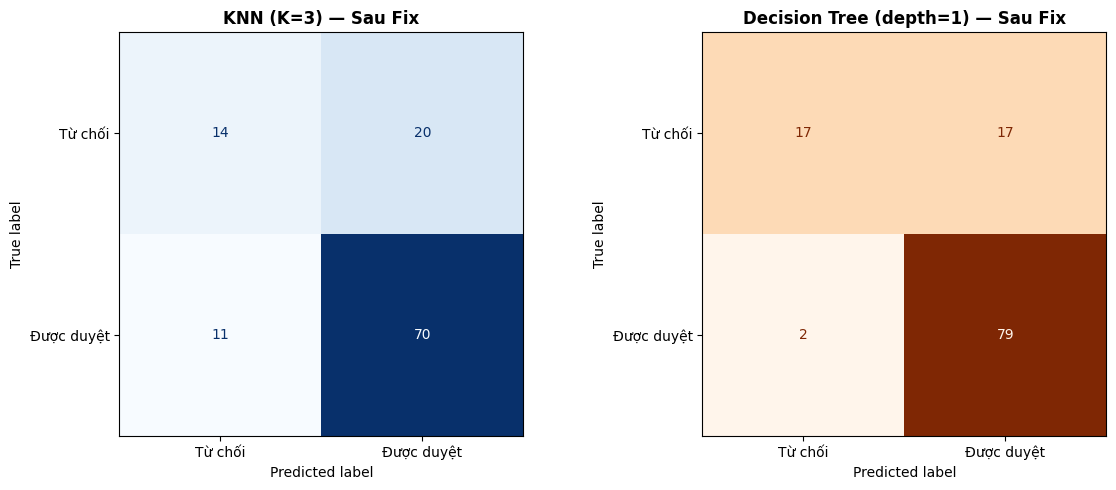

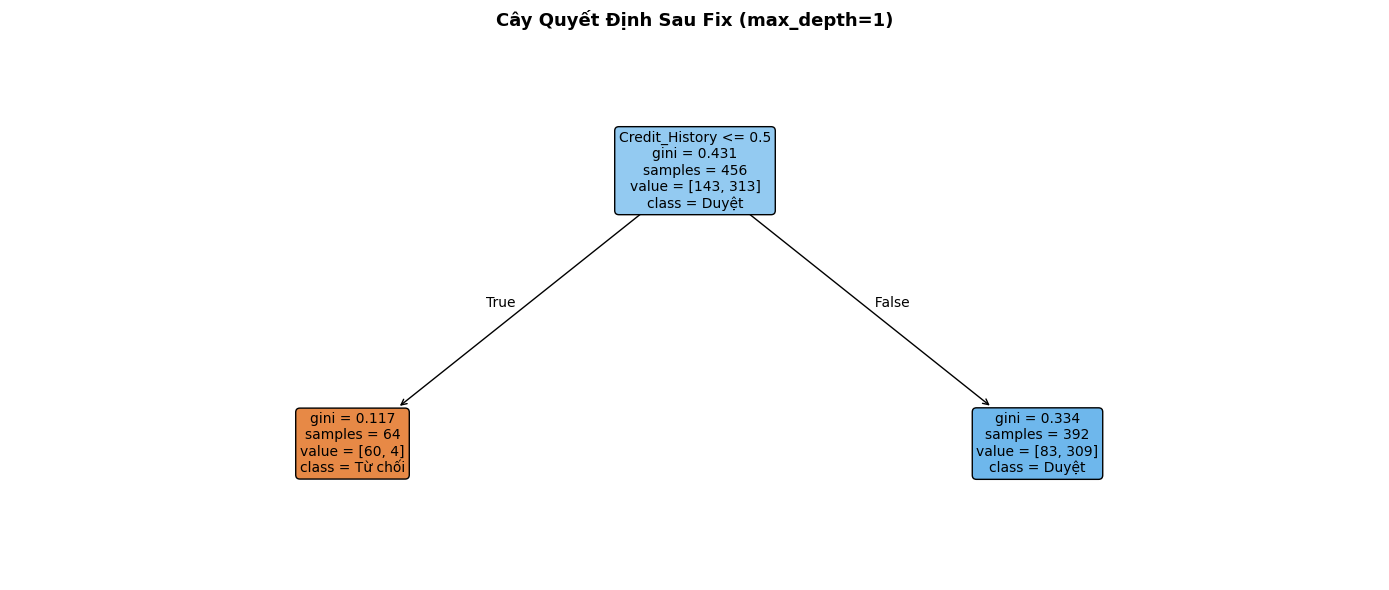

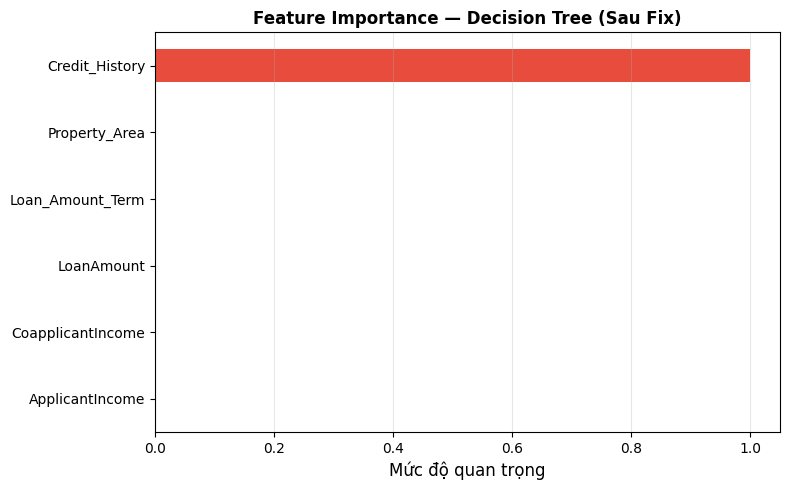

In [8]:
# ============================================================
# CELL 7 — BƯỚC 5: FIX BẰNG COLUMNTRANSFORMER → CHẠY LẠI
# ============================================================
continuous_cols  = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']
categorical_cols = ['Credit_History', 'Property_Area']

preprocessor = ColumnTransformer(transformers=[
    ('scale_continuous', StandardScaler(), continuous_cols),
    ('keep_categorical', 'passthrough',    categorical_cols)
])

X_train = preprocessor.fit_transform(X_train_raw)
X_test  = preprocessor.transform(X_test_raw)
feature_names_out = continuous_cols + categorical_cols

print('=== PIPELINE SAU KHI FIX ===')
print(f'Scale   : {continuous_cols}')
print(f'Giữ nguyên: {categorical_cols}')
ch_idx = feature_names_out.index('Credit_History')
print(f'Credit_History sau fix — unique values: {np.unique(X_train[:, ch_idx])} ✅')
print()

# KNN sau fix
knn_f1_cv = []
kf = StratifiedKFold(n_splits=5, shuffle=False)
for k in k_range:
    fold_f1 = []
    for train_fold, val_fold in kf.split(X_train, y_train):
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X_train[train_fold], y_train.iloc[train_fold])
        fold_f1.append(f1_score(y_train.iloc[val_fold],
                                knn.predict(X_train[val_fold])))
    knn_f1_cv.append(np.mean(fold_f1))

best_k = list(k_range)[np.argmax(knn_f1_cv)]
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train, y_train)
y_pred_knn = knn_best.predict(X_test)
acc_knn = accuracy_score(y_test, y_pred_knn)
f1_knn  = f1_score(y_test, y_pred_knn)

# DT sau fix
dt_f1_cv = []
for depth in depth_range:
    fold_f1 = []
    for train_fold, val_fold in kf.split(X_train, y_train):
        dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
        dt.fit(X_train[train_fold], y_train.iloc[train_fold])
        fold_f1.append(f1_score(y_train.iloc[val_fold],
                                dt.predict(X_train[val_fold])))
    dt_f1_cv.append(np.mean(fold_f1))

best_depth = list(depth_range)[np.argmax(dt_f1_cv)]
dt_best = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt_best.fit(X_train, y_train)
y_pred_dt = dt_best.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)
f1_dt  = f1_score(y_test, y_pred_dt)

print('=== SO SÁNH TRƯỚC VÀ SAU KHI FIX ===')
print(f'{"":30} {"Scale Sai":>12} {"Scale Đúng":>12}')
print('-' * 56)
print(f'{"KNN F1-score":<30} {f1_knn_wrong*100:>11.2f}% {f1_knn*100:>11.2f}%')
print(f'{"DT  F1-score":<30} {f1_dt_wrong*100:>11.2f}% {f1_dt*100:>11.2f}%')
print(f'{"2 mô hình giống nhau?":<30} {"✅ Có":>12} {"❌ Không":>12}')
print()

# Confusion matrix và cây sau fix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_knn),
    display_labels=['Từ chối', 'Được duyệt']
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'KNN (K={best_k}) — Sau Fix', fontweight='bold')

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_dt),
    display_labels=['Từ chối', 'Được duyệt']
).plot(ax=axes[1], colorbar=False, cmap='Oranges')
axes[1].set_title(f'Decision Tree (depth={best_depth}) — Sau Fix', fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_after_fix.png', dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(14, 6))
plot_tree(dt_best, feature_names=feature_names_out,
          class_names=['Từ chối', 'Duyệt'],
          filled=True, rounded=True, fontsize=10, ax=ax)
ax.set_title(f'Cây Quyết Định Sau Fix (max_depth={best_depth})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cay_quyet_dinh_after_fix.png', dpi=150)
plt.show()

# Feature Importance
importances = pd.Series(dt_best.feature_importances_,
                        index=feature_names_out).sort_values()
plt.figure(figsize=(8, 5))
colors = ['#e74c3c' if v == importances.max() else '#3498db' for v in importances]
importances.plot(kind='barh', color=colors)
plt.xlabel('Mức độ quan trọng', fontsize=12)
plt.title('Feature Importance — Decision Tree (Sau Fix)', fontweight='bold')
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance_dt.png', dpi=150)
plt.show()

✅ File Phần 3: K=3 | Acc=75.65% | F1=83.33%

   SO SÁNH 1: KNN TỰ CODE vs SKLEARN (cùng K)
Mô hình                               Accuracy   F1-score
--------------------------------------------------------------------
KNN Tự Code (Phần 3, K=3)               75.65%     83.33%
KNN Sklearn (K=3) ← cùng K              73.04%     81.87%

Chênh lệch F1-score: 1.46%
✅ Kết quả khớp → Thuật toán tự code CHÍNH XÁC!


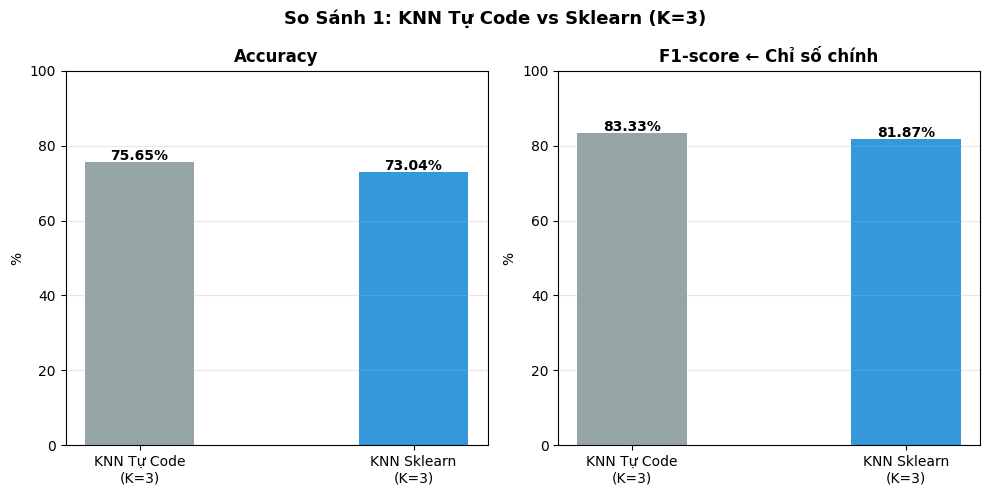

In [9]:
# ============================================================
# CELL 8 — SO SÁNH 1: KNN TỰ CODE vs SKLEARN (kiểm chứng)
# ============================================================
try:
    phan3  = pd.read_csv('ket_qua_phan3.csv')
    acc_p3 = float(phan3['accuracy'].iloc[0])
    f1_p3  = float(phan3['f1_score'].iloc[0])
    k_p3   = int(phan3['k'].iloc[0])
    print(f'✅ File Phần 3: K={k_p3} | Acc={acc_p3*100:.2f}% | F1={f1_p3*100:.2f}%')
except:
    print('⚠️  Chưa có ket_qua_phan3.csv → dùng giá trị tạm')
    acc_p3, f1_p3, k_p3 = 0.7826, 0.8485, 3

knn_k3 = KNeighborsClassifier(n_neighbors=k_p3)
knn_k3.fit(X_train, y_train)
y_pred_k3 = knn_k3.predict(X_test)
acc_k3    = accuracy_score(y_test, y_pred_k3)
f1_k3     = f1_score(y_test, y_pred_k3)

print()
print('=' * 68)
print('   SO SÁNH 1: KNN TỰ CODE vs SKLEARN (cùng K)')
print('=' * 68)
print(f'{"Mô hình":<35} {"Accuracy":>10} {"F1-score":>10}')
print('-' * 68)
print(f'{"KNN Tự Code (Phần 3, K="+str(k_p3)+")":<35} {acc_p3*100:>9.2f}% {f1_p3*100:>9.2f}%')
print(f'{"KNN Sklearn (K="+str(k_p3)+") ← cùng K":<35} {acc_k3*100:>9.2f}% {f1_k3*100:>9.2f}%')
print('=' * 68)

diff_f1 = abs(f1_p3 - f1_k3) * 100
print(f'\nChênh lệch F1-score: {diff_f1:.2f}%')
if diff_f1 <= 3:
    print('✅ Kết quả khớp → Thuật toán tự code CHÍNH XÁC!')
else:
    print('⚠️  Chênh lệch lớn → Kiểm tra lại logic hoặc cách chia data Phần 3')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
labels = [f'KNN Tự Code\n(K={k_p3})', f'KNN Sklearn\n(K={k_p3})']
colors = ['#95a5a6', '#3498db']
ax1.bar(labels, [acc_p3*100, acc_k3*100], color=colors, width=0.4)
for i, v in enumerate([acc_p3*100, acc_k3*100]):
    ax1.text(i, v+0.5, f'{v:.2f}%', ha='center', fontweight='bold')
ax1.set_ylim(0, 100); ax1.set_title('Accuracy', fontweight='bold')
ax1.set_ylabel('%'); ax1.grid(True, axis='y', alpha=0.3)
ax2.bar(labels, [f1_p3*100, f1_k3*100], color=colors, width=0.4)
for i, v in enumerate([f1_p3*100, f1_k3*100]):
    ax2.text(i, v+0.5, f'{v:.2f}%', ha='center', fontweight='bold')
ax2.set_ylim(0, 100); ax2.set_title('F1-score ← Chỉ số chính', fontweight='bold')
ax2.set_ylabel('%'); ax2.grid(True, axis='y', alpha=0.3)
plt.suptitle(f'So Sánh 1: KNN Tự Code vs Sklearn (K={k_p3})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('so_sanh_1_kiem_chung.png', dpi=150)
plt.show()

   SO SÁNH 2: KNN SKLEARN vs DECISION TREE (sau fix)
Mô hình                               Accuracy   F1-score
--------------------------------------------------------------------
KNN Sklearn (K=3)                       73.04%     81.87%
Decision Tree (depth=1)                 83.48%     89.27%

🏆 Decision Tree tốt hơn: F1=89.27%


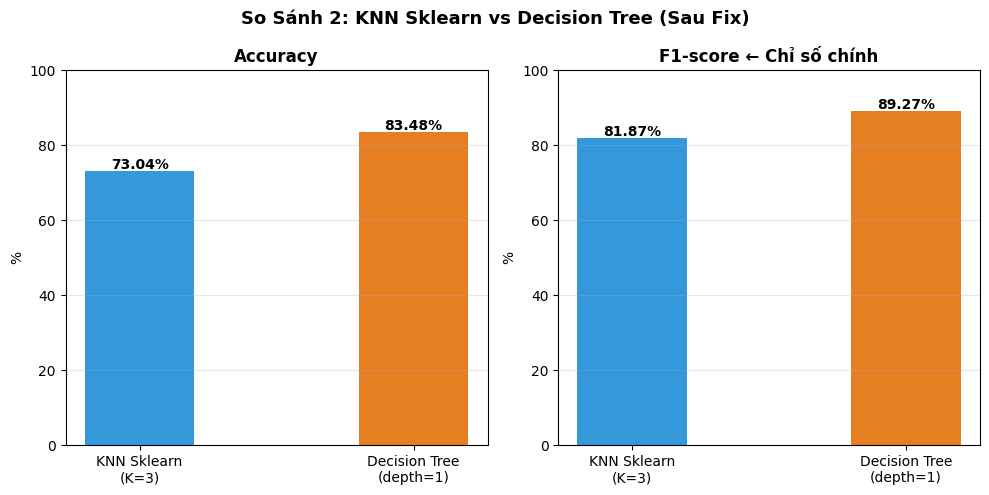

In [10]:
# ============================================================
# CELL 9 — SO SÁNH 2: KNN SKLEARN vs DECISION TREE (sau fix)
# ============================================================
print('=' * 68)
print('   SO SÁNH 2: KNN SKLEARN vs DECISION TREE (sau fix)')
print('=' * 68)
print(f'{"Mô hình":<35} {"Accuracy":>10} {"F1-score":>10}')
print('-' * 68)
print(f'{"KNN Sklearn (K="+str(best_k)+")":<35} {acc_knn*100:>9.2f}% {f1_knn*100:>9.2f}%')
print(f'{"Decision Tree (depth="+str(best_depth)+")":<35} {acc_dt*100:>9.2f}% {f1_dt*100:>9.2f}%')
print('=' * 68)

if f1_dt > f1_knn:
    print(f'\n🏆 Decision Tree tốt hơn: F1={f1_dt*100:.2f}%')
elif f1_knn > f1_dt:
    print(f'\n🏆 KNN tốt hơn: F1={f1_knn*100:.2f}%')
else:
    print(f'\n🤝 Hai mô hình tương đương: F1={f1_knn*100:.2f}%')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
labels = [f'KNN Sklearn\n(K={best_k})', f'Decision Tree\n(depth={best_depth})']
colors = ['#3498db', '#e67e22']
ax1.bar(labels, [acc_knn*100, acc_dt*100], color=colors, width=0.4)
for i, v in enumerate([acc_knn*100, acc_dt*100]):
    ax1.text(i, v+0.5, f'{v:.2f}%', ha='center', fontweight='bold')
ax1.set_ylim(0, 100); ax1.set_title('Accuracy', fontweight='bold')
ax1.set_ylabel('%'); ax1.grid(True, axis='y', alpha=0.3)
ax2.bar(labels, [f1_knn*100, f1_dt*100], color=colors, width=0.4)
for i, v in enumerate([f1_knn*100, f1_dt*100]):
    ax2.text(i, v+0.5, f'{v:.2f}%', ha='center', fontweight='bold')
ax2.set_ylim(0, 100); ax2.set_title('F1-score ← Chỉ số chính', fontweight='bold')
ax2.set_ylabel('%'); ax2.grid(True, axis='y', alpha=0.3)
plt.suptitle('So Sánh 2: KNN Sklearn vs Decision Tree (Sau Fix)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('so_sanh_2_thuat_toan.png', dpi=150)
plt.show()

In [11]:
# ============================================================
# CELL 10 — LƯU KẾT QUẢ VÀO SQLITE
# ============================================================
try:
    conn.close()
except:
    pass

import sqlite3
conn   = sqlite3.connect('QuanLyTinDung.db')
cursor = conn.cursor()

cursor.execute('DROP TABLE IF EXISTS du_doan')
cursor.execute('DROP TABLE IF EXISTS xac_suat')

cursor.execute("""
CREATE TABLE du_doan (
    ID                INTEGER PRIMARY KEY AUTOINCREMENT,
    ApplicantIncome   REAL,
    CoapplicantIncome REAL,
    LoanAmount        REAL,
    Loan_Amount_Term  REAL,
    Credit_History    REAL,
    Property_Area     INTEGER,
    KetQuaThucTe      INTEGER,
    DuDoan_KNN        INTEGER,
    DuDoan_DT         INTEGER
)
""")

cursor.execute("""
CREATE TABLE xac_suat (
    ID        INTEGER PRIMARY KEY AUTOINCREMENT,
    TenMoHinh TEXT,
    ThamSo    TEXT,
    Loai      TEXT,
    Accuracy  REAL,
    F1_Score  REAL
)
""")

conn.commit()
print('✅ Đã tạo 2 bảng: du_doan + xac_suat')

df_result = X_test_raw.copy().reset_index(drop=True)
df_result['KetQuaThucTe'] = y_test.values
df_result['DuDoan_KNN']   = y_pred_knn
df_result['DuDoan_DT']    = y_pred_dt

for _, row in df_result.iterrows():
    cursor.execute(
        'INSERT INTO du_doan VALUES (NULL,?,?,?,?,?,?,?,?,?)',
        (
            float(row['ApplicantIncome']),
            float(row['CoapplicantIncome']),
            float(row['LoanAmount']),
            float(row['Loan_Amount_Term']),
            float(row['Credit_History']),
            int(row['Property_Area']),
            int(row['KetQuaThucTe']),
            int(row['DuDoan_KNN']),
            int(row['DuDoan_DT']),
        )
    )

models = [
    ('KNN Tự Code',   f'K={k_p3}',           'Tự cài đặt', acc_p3,  f1_p3),
    ('KNN Sklearn',   f'K={k_p3}',           'Thư viện',   acc_k3,  f1_k3),
    ('KNN Sklearn',   f'K={best_k}',         'Thư viện',   acc_knn, f1_knn),
    ('Decision Tree', f'depth={best_depth}', 'Thư viện',   acc_dt,  f1_dt),
]
for row in models:
    cursor.execute('INSERT INTO xac_suat VALUES (NULL,?,?,?,?,?)', row)

conn.commit()
print(f'✅ Đã lưu {len(df_result)} hồ sơ vào du_doan')
print(f'✅ Đã lưu {len(models)} mô hình vào xac_suat')

print('\n--- Kết quả các mô hình ---')
print(pd.read_sql("""
    SELECT TenMoHinh, ThamSo, Loai,
           ROUND(Accuracy*100,2) as Accuracy,
           ROUND(F1_Score*100,2) as F1_Score
    FROM xac_suat
""", conn).to_string(index=False))

conn.close()
print('\n✅ Đã lưu QuanLyTinDung.db!')

✅ Đã tạo 2 bảng: du_doan + xac_suat
✅ Đã lưu 115 hồ sơ vào du_doan
✅ Đã lưu 4 mô hình vào xac_suat

--- Kết quả các mô hình ---
    TenMoHinh  ThamSo       Loai  Accuracy  F1_Score
  KNN Tự Code     K=3 Tự cài đặt     75.65     83.33
  KNN Sklearn     K=3   Thư viện     73.04     81.87
  KNN Sklearn     K=3   Thư viện     73.04     81.87
Decision Tree depth=1   Thư viện     83.48     89.27

✅ Đã lưu QuanLyTinDung.db!
